In [1]:
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

from app.config.config import (
    WEIGHTS_PATH,
    DEVICE,
    CONF,
    IOU,
    IMG_SIZE
)

from app.detection.face_detector import FaceDetector
from app.recognition.face_recognizer import FaceRecognizer

In [2]:
detector = FaceDetector(
    Path(WEIGHTS_PATH),
    device=DEVICE,
    conf=0.25,
    iou=0.5,
    img_size=640
)

recognizer = FaceRecognizer(device=DEVICE)

print("Models loaded successfully.")

[MODEL] Input  — name: input.1, shape: ['None', 3, 112, 112], type: tensor(float)
[MODEL] Output — name: 683, shape: [1, 512], type: tensor(float)
Models loaded successfully.


In [3]:
def extract_face_crop(frame):
    detections = detector.predict(frame)

    if len(detections) == 0:
        return None

    det = detections[0]

    x1, y1, x2, y2 = map(
        int,
        [det["x1"], det["y1"], det["x2"], det["y2"]]
    )

    pad = 10

    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(frame.shape[1], x2 + pad)
    y2 = min(frame.shape[0], y2 + pad)

    crop = frame[y1:y2, x1:x2]

    if crop.size == 0:
        return None

    crop = cv2.resize(crop, (112,112))

    return crop

(-0.5, 224.5, 224.5, -0.5)

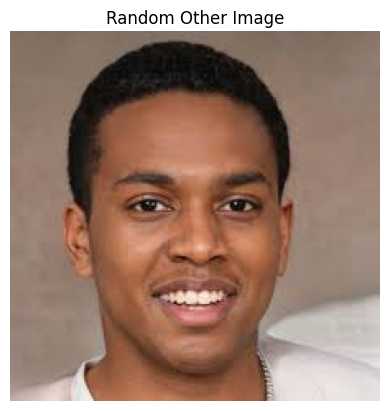

In [5]:
image = cv2.imread("random_other.jpg")

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Random Other Image")
plt.axis("off")

Detected 1 face(s)


(-0.5, 224.5, 224.5, -0.5)

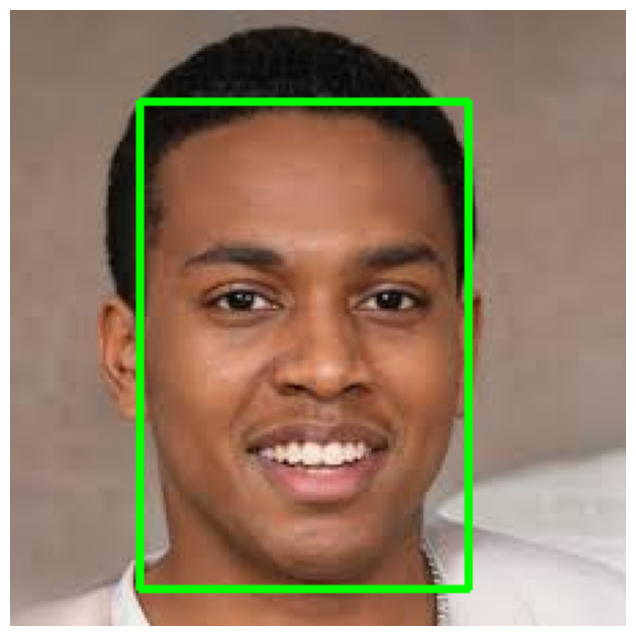

In [6]:
detections = detector.predict(image)

display = image.copy()

for det in detections:

    x1 = int(det["x1"])
    y1 = int(det["y1"])
    x2 = int(det["x2"])
    y2 = int(det["y2"])

    cv2.rectangle(display,(x1,y1),(x2,y2),(0,255,0),2)

print(f"Detected {len(detections)} face(s)")

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(display,cv2.COLOR_BGR2RGB))
plt.axis("off")

(-0.5, 111.5, 111.5, -0.5)

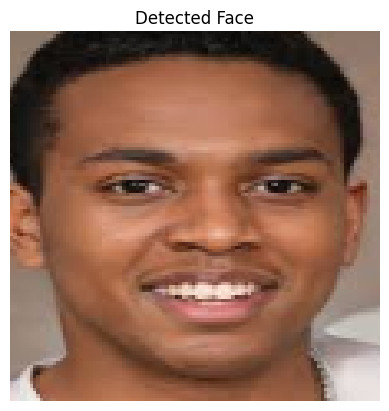

In [7]:
face = extract_face_crop(image)

plt.imshow(cv2.cvtColor(face,cv2.COLOR_BGR2RGB))
plt.title("Detected Face")
plt.axis("off")

In [8]:
embedding = recognizer.get_embedding(face)

print("Embedding Shape :", embedding.shape)

print()

print(embedding[:15])

Embedding Shape : (512,)

[   0.029889    0.031258      0.0119  -0.0065428   -0.060332   -0.053264    0.025853   -0.022426   -0.021255       0.011     0.02061    0.035008    0.031454   -0.019442   -0.016751]


In [9]:
img1 = cv2.imread("Ben_Affleck_0004.jpg")
img2 = cv2.imread("Ben_Affleck_0005.jpg")
img3 = cv2.imread("random_other.jpg")

In [10]:
face1 = extract_face_crop(img1)
face2 = extract_face_crop(img2)
face3 = extract_face_crop(img3)

In [11]:
emb1 = recognizer.get_embedding(face1)
emb2 = recognizer.get_embedding(face2)
emb3 = recognizer.get_embedding(face3)

In [12]:
from numpy.linalg import norm

def cosine_similarity(a, b):
    return float(np.dot(a, b) / (norm(a) * norm(b)))

In [13]:
same = cosine_similarity(emb1, emb2)
different = cosine_similarity(emb1, emb3)

print(f"Same Person Similarity      : {same:.4f}")
print(f"Different Person Similarity : {different:.4f}")

Same Person Similarity      : 0.5506
Different Person Similarity : 0.0353


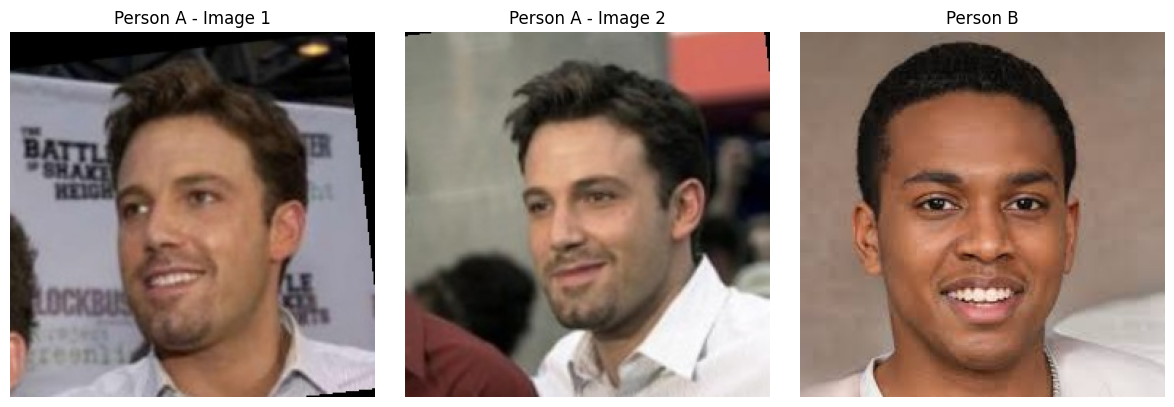

In [14]:
fig, ax = plt.subplots(1,3, figsize=(12,4))

titles = [
    "Person A - Image 1",
    "Person A - Image 2",
    "Person B"
]

for axis, img, title in zip(ax, [img1, img2, img3], titles):
    axis.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()

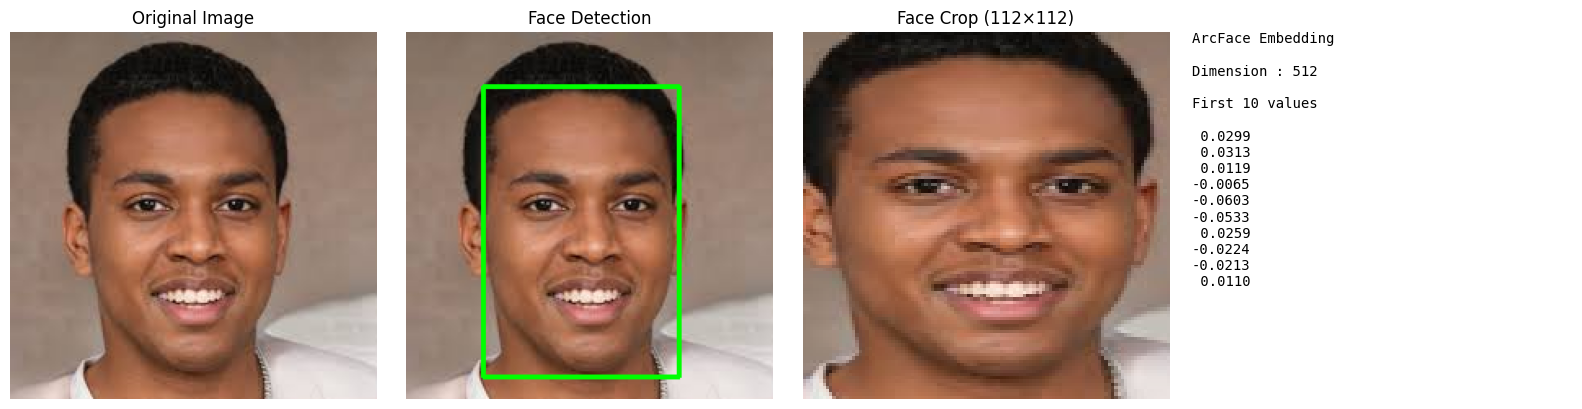

In [15]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

display = image.copy()

detections = detector.predict(image)

det = detections[0]

x1,y1,x2,y2 = map(
    int,
    [det["x1"],det["y1"],det["x2"],det["y2"]]
)

cv2.rectangle(display,(x1,y1),(x2,y2),(0,255,0),2)

fig = plt.figure(figsize=(16,4))

ax1 = fig.add_subplot(1,4,1)
ax1.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
ax1.set_title("Original Image")
ax1.axis("off")

ax2 = fig.add_subplot(1,4,2)
ax2.imshow(cv2.cvtColor(display,cv2.COLOR_BGR2RGB))
ax2.set_title("Face Detection")
ax2.axis("off")

ax3 = fig.add_subplot(1,4,3)
ax3.imshow(cv2.cvtColor(face,cv2.COLOR_BGR2RGB))
ax3.set_title("Face Crop (112×112)")
ax3.axis("off")

ax4 = fig.add_subplot(1,4,4)

text = (
    "ArcFace Embedding\n\n"
    f"Dimension : {embedding.shape[0]}\n\n"
    "First 10 values\n\n"
)

for i in range(10):
    text += f"{embedding[i]: .4f}\n"

ax4.text(
    0,
    1,
    text,
    fontsize=10,
    va="top",
    family="monospace"
)

ax4.axis("off")

plt.tight_layout()

plt.savefig(
    "pipeline_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

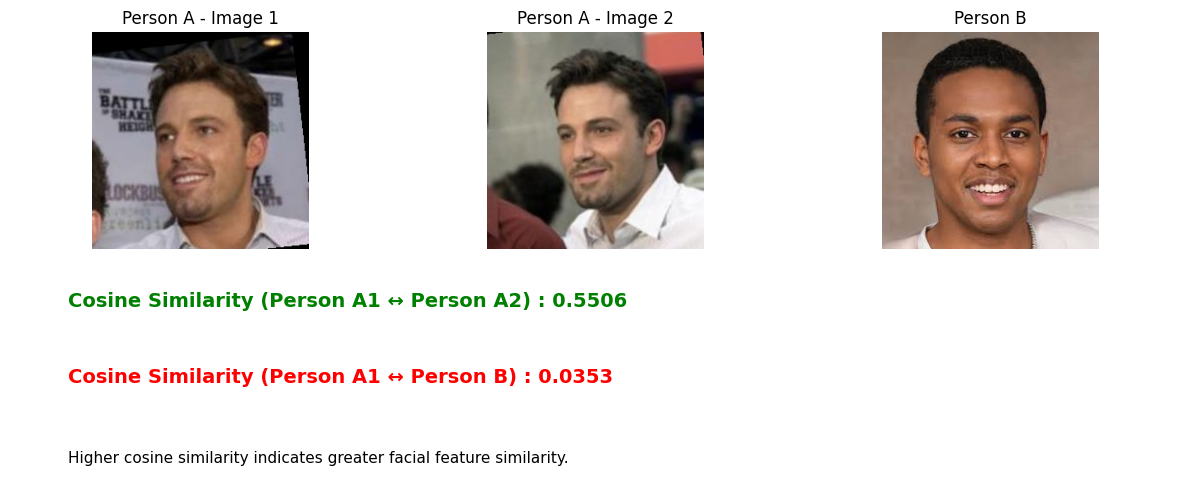

In [16]:
fig = plt.figure(figsize=(12,5))

titles = [
    "Person A - Image 1",
    "Person A - Image 2",
    "Person B"
]

images = [img1,img2,img3]

for i in range(3):

    ax = fig.add_subplot(2,3,i+1)

    ax.imshow(cv2.cvtColor(images[i],cv2.COLOR_BGR2RGB))
    ax.set_title(titles[i])
    ax.axis("off")

score_ax = fig.add_subplot(2,1,2)

score_ax.axis("off")

score_ax.text(
    0.05,
    0.8,
    f"Cosine Similarity (Person A1 ↔ Person A2) : {same:.4f}",
    fontsize=14,
    color="green",
    weight="bold"
)

score_ax.text(
    0.05,
    0.45,
    f"Cosine Similarity (Person A1 ↔ Person B) : {different:.4f}",
    fontsize=14,
    color="red",
    weight="bold"
)

score_ax.text(
    0.05,
    0.08,
    "Higher cosine similarity indicates greater facial feature similarity.",
    fontsize=11
)

plt.tight_layout()

plt.savefig(
    "cosine_similarity_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
heatmap = embedding.reshape(16, 32)

ax4.imshow(heatmap, cmap="viridis", aspect="auto")
ax4.set_title("512-D ArcFace Embedding")
ax4.set_xticks([])
ax4.set_yticks([])

[]

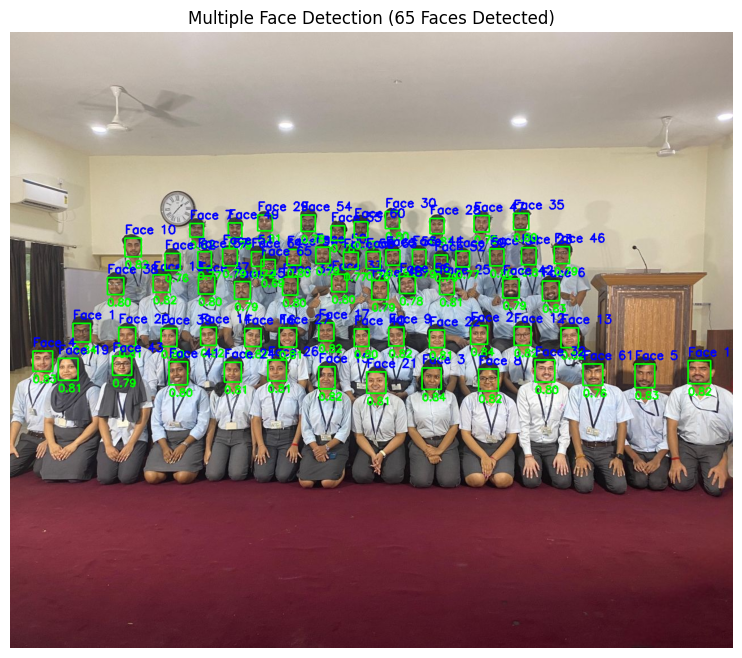

In [18]:
image = cv2.imread("test5.jpg")

if image is None:
    raise FileNotFoundError("Image not found.")

detections = detector.predict(image)

display = image.copy()

for i, det in enumerate(detections, start=1):

    x1 = int(det["x1"])
    y1 = int(det["y1"])
    x2 = int(det["x2"])
    y2 = int(det["y2"])

    confidence = det["conf"]

    # Bounding Box
    cv2.rectangle(display, (x1, y1), (x2, y2), (0, 255, 0), 2)

    # Face Number
    cv2.putText(
        display,
        f"Face {i}",
        (x1, max(25, y1 - 8)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 0, 0),
        2
    )

    # Confidence
    cv2.putText(
        display,
        f"{confidence:.2f}",
        (x1, y2 + 20),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (0, 255, 0),
        2
    )

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
plt.title(f"Multiple Face Detection ({len(detections)} Faces Detected)")
plt.axis("off")
plt.show()

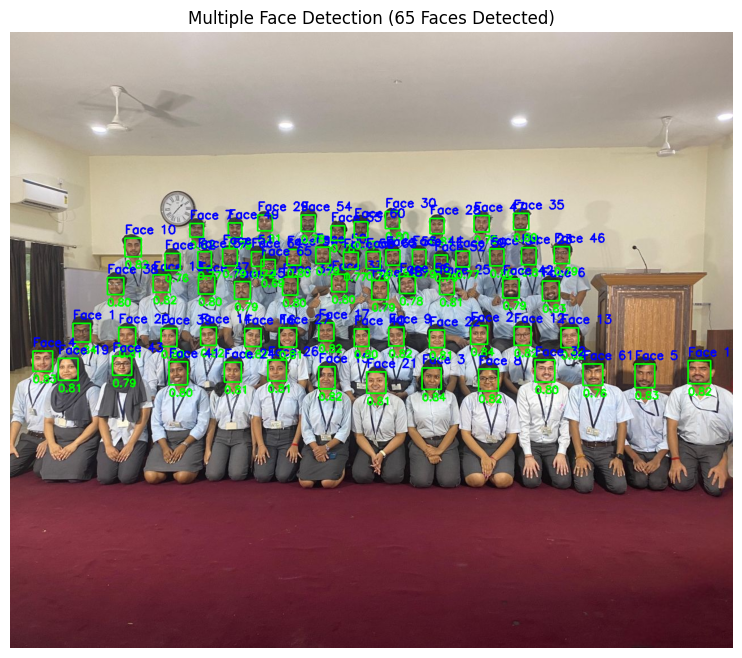

In [19]:
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
plt.title(f"Multiple Face Detection ({len(detections)} Faces Detected)")
plt.axis("off")

plt.savefig(
    "multiple_face_detection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()